In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [10]:
import pandas as pd
from google.colab import files

print("Please select your CSV file to upload:")
uploaded = files.upload()

Please select your CSV file to upload:


Saving data.csv to data (1).csv


In [11]:
filename = list(uploaded.keys())[0]
print(f"Uploaded file: {filename}")

data = pd.read_csv(filename)

print(f"\nDataset shape: {data.shape}")
print(f"Columns: {list(data.columns)}")

data.head()

print("\nBasic info:")
print(data.info())

Uploaded file: data (1).csv

Dataset shape: (569, 33)
Columns: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean       

In [12]:
data.drop(['Unnamed: 32',"id"], axis=1, inplace=True)
data.diagnosis = [1 if each == "M" else 0 for each in data.diagnosis]
y = data.diagnosis.values
x_data = data.drop(['diagnosis'], axis=1)

In [15]:
x = (x_data -np.min(x_data))/(np.max(x_data)-np.min(x_data))

In [16]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

x_train = x_train.T
x_test = x_test.T
y_train = y_train.T
y_test = y_test.T

print("x train: ",x_train.shape)
print("x test: ",x_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (30, 483)
x test:  (30, 86)
y train:  (483,)
y test:  (86,)


In [17]:
def initialize_weights_and_bias(dimension):
    w = np.full((dimension,1),0.01)
    b = 0.0
    return w, b

In [18]:
def sigmoid(z):
    y_head = 1/(1+np.exp(-z))
    return y_head

In [19]:
def forward_backward_propagation(w,b,x_train,y_train):
    z = np.dot(w.T,x_train) + b
    y_head = sigmoid(z)
    loss = -y_train*np.log(y_head)-(1-y_train)*np.log(1-y_head)
    cost = (np.sum(loss))/x_train.shape[1]
    derivative_weight = (np.dot(x_train,((y_head-y_train).T)))/x_train.shape[1]
    derivative_bias = np.sum(y_head-y_train)/x_train.shape[1]
    gradients = {"derivative_weight": derivative_weight,"derivative_bias": derivative_bias}
    return cost,gradients

In [20]:
def update(w, b, x_train, y_train, learning_rate,number_of_iterarion):
    cost_list = []
    cost_list2 = []
    index = []
    for i in range(number_of_iterarion):
        cost,gradients = forward_backward_propagation(w,b,x_train,y_train)
        cost_list.append(cost)
        w = w - learning_rate * gradients["derivative_weight"]
        b = b - learning_rate * gradients["derivative_bias"]
        if i % 10 == 0:
            cost_list2.append(cost)
            index.append(i)
            print ("Cost after iteration %i: %f" %(i, cost))
    parameters = {"weight": w,"bias": b}
    plt.plot(index,cost_list2)
    plt.xticks(index,rotation='vertical')
    plt.xlabel("Number of Iterarion")
    plt.ylabel("Cost")
    plt.show()
    return parameters, gradients, cost_list

In [21]:
def predict(w,b,x_test):
    z = sigmoid(np.dot(w.T,x_test)+b)
    Y_prediction = np.zeros((1,x_test.shape[1]))
    for i in range(z.shape[1]):
        if z[0,i]<= 0.5:
            Y_prediction[0,i] = 0
        else:
            Y_prediction[0,i] = 1

    return Y_prediction

Cost after iteration 0: 0.692860
Cost after iteration 10: 0.638692
Cost after iteration 20: 0.613871
Cost after iteration 30: 0.591776
Cost after iteration 40: 0.572024
Cost after iteration 50: 0.554314
Cost after iteration 60: 0.538375
Cost after iteration 70: 0.523968
Cost after iteration 80: 0.510891
Cost after iteration 90: 0.498971


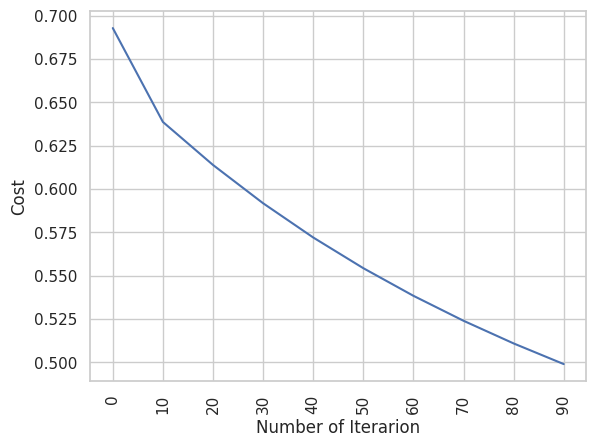

train accuracy: 80.74534161490683 %
test accuracy: 81.3953488372093 %


In [22]:
def logistic_regression(x_train, y_train, x_test, y_test, learning_rate ,  num_iterations):
    dimension =  x_train.shape[0]  # that is 4096
    w,b = initialize_weights_and_bias(dimension)
    parameters, gradients, cost_list = update(w, b, x_train, y_train, learning_rate,num_iterations)

    y_prediction_test = predict(parameters["weight"],parameters["bias"],x_test)
    y_prediction_train = predict(parameters["weight"],parameters["bias"],x_train)

    print("train accuracy: {} %".format(100 - np.mean(np.abs(y_prediction_train - y_train)) * 100))
    print("test accuracy: {} %".format(100 - np.mean(np.abs(y_prediction_test - y_test)) * 100))

logistic_regression(x_train, y_train, x_test, y_test,learning_rate = 1, num_iterations = 100)

In [23]:
from sklearn import linear_model
logreg = linear_model.LogisticRegression(random_state = 42,max_iter= 150)
print("test accuracy: {} ".format(logreg.fit(x_train.T, y_train.T).score(x_test.T, y_test.T)))
print("train accuracy: {} ".format(logreg.fit(x_train.T, y_train.T).score(x_train.T, y_train.T)))

test accuracy: 0.8953488372093024 
train accuracy: 0.8633540372670807 


Cost after iteration 0: 0.692860
Cost after iteration 10: 0.638692
Cost after iteration 20: 0.613871
Cost after iteration 30: 0.591776
Cost after iteration 40: 0.572024
Cost after iteration 50: 0.554314
Cost after iteration 60: 0.538375
Cost after iteration 70: 0.523968
Cost after iteration 80: 0.510891
Cost after iteration 90: 0.498971


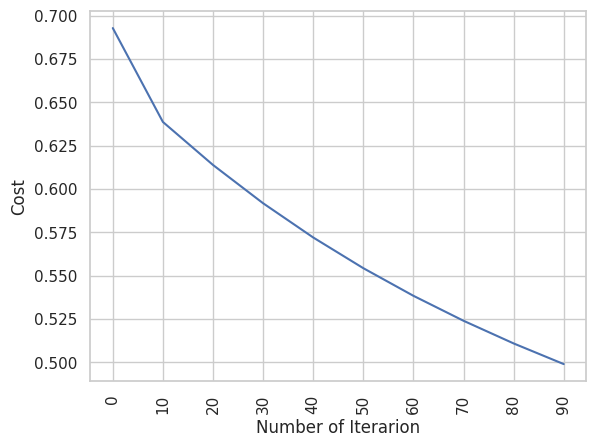

=== Custom Logistic Regression Confusion Matrix ===

Test Set Confusion Matrix:
[[54  0]
 [16 16]]

Train Set Confusion Matrix:
[[303   0]
 [ 93  87]]


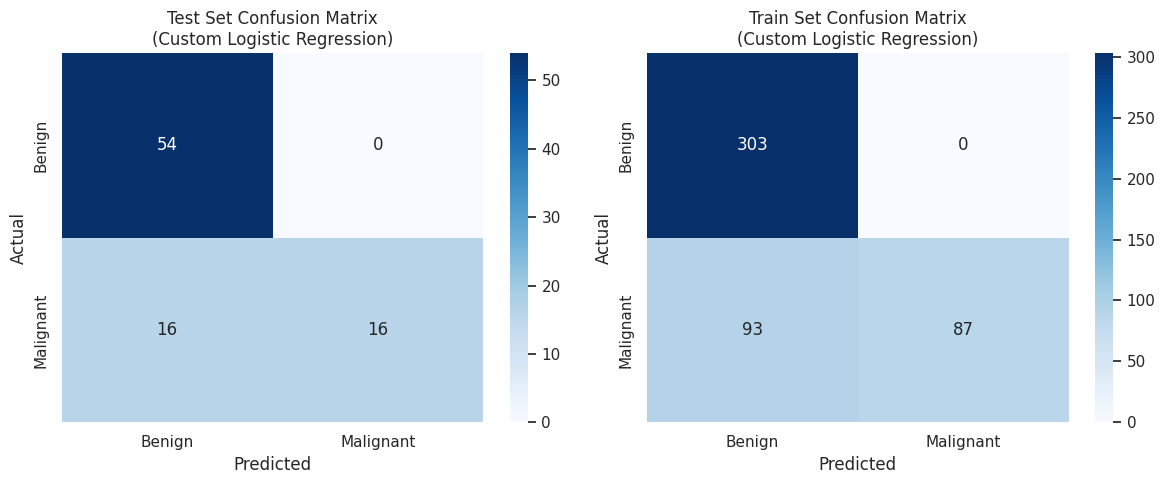


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

      Benign       0.77      1.00      0.87        54
   Malignant       1.00      0.50      0.67        32

    accuracy                           0.81        86
   macro avg       0.89      0.75      0.77        86
weighted avg       0.86      0.81      0.79        86


=== Sklearn Logistic Regression Confusion Matrix ===

Test Set Confusion Matrix:
[[54  0]
 [ 9 23]]

Train Set Confusion Matrix:
[[302   1]
 [ 65 115]]


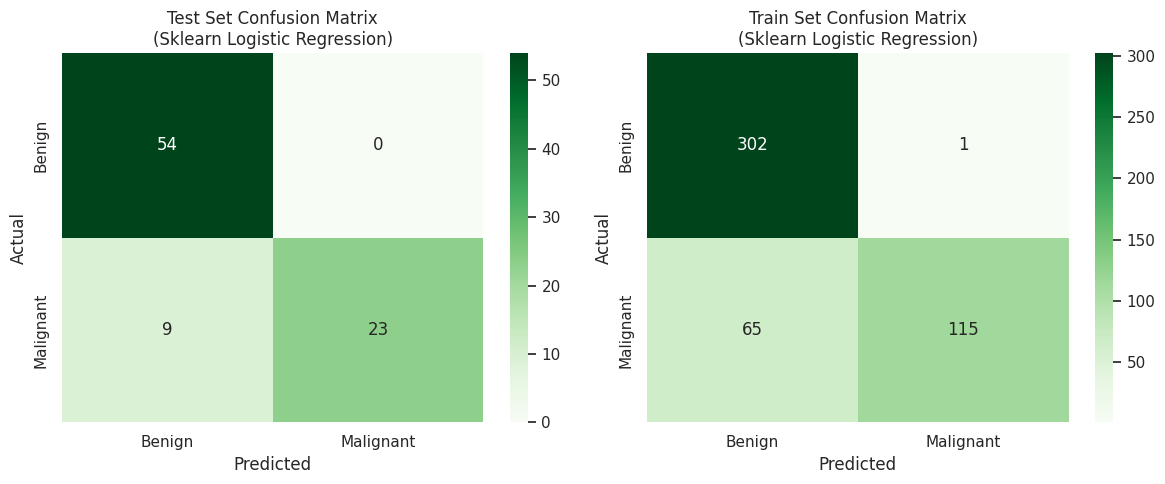


=== Model Comparison ===
Custom Logistic Regression:
Test Accuracy: 81.40%
Train Accuracy: 80.75%

Sklearn Logistic Regression:
Test Accuracy: 89.53%
Train Accuracy: 86.34%

=== Detailed Metrics Comparison ===

Custom Logistic Regression (Test Set):
Accuracy: 0.8140
Precision: 1.0000
Recall (Sensitivity): 0.5000
Specificity: 1.0000
F1-Score: 0.6667

Sklearn Logistic Regression (Test Set):
Accuracy: 0.8953
Precision: 1.0000
Recall (Sensitivity): 0.7188
Specificity: 1.0000
F1-Score: 0.8364


In [24]:
# Cell 14: Import required libraries for confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Cell 15: Get predictions from your custom logistic regression model
def get_final_predictions(x_train, y_train, x_test, y_test, learning_rate, num_iterations):
    dimension = x_train.shape[0]
    w, b = initialize_weights_and_bias(dimension)
    parameters, gradients, cost_list = update(w, b, x_train, y_train, learning_rate, num_iterations)

    y_prediction_test = predict(parameters["weight"], parameters["bias"], x_test)
    y_prediction_train = predict(parameters["weight"], parameters["bias"], x_train)

    return y_prediction_test, y_prediction_train

# Get predictions
y_pred_test, y_pred_train = get_final_predictions(x_train, y_train, x_test, y_test, learning_rate=1, num_iterations=100)

# Cell 16: Create confusion matrix for custom logistic regression
print("=== Custom Logistic Regression Confusion Matrix ===")
print("\nTest Set Confusion Matrix:")
cm_test = confusion_matrix(y_test, y_pred_test.T)
print(cm_test)

print("\nTrain Set Confusion Matrix:")
cm_train = confusion_matrix(y_train, y_pred_train.T)
print(cm_train)

# Cell 17: Visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Test set confusion matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'], ax=axes[0])
axes[0].set_title('Test Set Confusion Matrix\n(Custom Logistic Regression)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Train set confusion matrix
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'], ax=axes[1])
axes[1].set_title('Train Set Confusion Matrix\n(Custom Logistic Regression)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Cell 18: Detailed classification report
print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test.T, target_names=['Benign', 'Malignant']))

# Cell 19: Confusion matrix for sklearn logistic regression
print("\n=== Sklearn Logistic Regression Confusion Matrix ===")
logreg = linear_model.LogisticRegression(random_state=42, max_iter=150)
logreg.fit(x_train.T, y_train.T)

# Get predictions
y_pred_sklearn_test = logreg.predict(x_test.T)
y_pred_sklearn_train = logreg.predict(x_train.T)

print("\nTest Set Confusion Matrix:")
cm_sklearn_test = confusion_matrix(y_test, y_pred_sklearn_test)
print(cm_sklearn_test)

print("\nTrain Set Confusion Matrix:")
cm_sklearn_train = confusion_matrix(y_train, y_pred_sklearn_train)
print(cm_sklearn_train)

# Cell 20: Visualize sklearn confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Test set confusion matrix
sns.heatmap(cm_sklearn_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'], ax=axes[0])
axes[0].set_title('Test Set Confusion Matrix\n(Sklearn Logistic Regression)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Train set confusion matrix
sns.heatmap(cm_sklearn_train, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'], ax=axes[1])
axes[1].set_title('Train Set Confusion Matrix\n(Sklearn Logistic Regression)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Cell 21: Compare both models
print("\n=== Model Comparison ===")
print("Custom Logistic Regression:")
print(f"Test Accuracy: {100 - np.mean(np.abs(y_pred_test - y_test)) * 100:.2f}%")
print(f"Train Accuracy: {100 - np.mean(np.abs(y_pred_train - y_train)) * 100:.2f}%")

print("\nSklearn Logistic Regression:")
print(f"Test Accuracy: {logreg.score(x_test.T, y_test.T) * 100:.2f}%")
print(f"Train Accuracy: {logreg.score(x_train.T, y_train.T) * 100:.2f}%")

# Cell 22: Calculate additional metrics
def calculate_metrics(cm):
    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return accuracy, precision, recall, specificity, f1_score

print("\n=== Detailed Metrics Comparison ===")
print("\nCustom Logistic Regression (Test Set):")
acc, prec, rec, spec, f1 = calculate_metrics(cm_test)
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall (Sensitivity): {rec:.4f}")
print(f"Specificity: {spec:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nSklearn Logistic Regression (Test Set):")
acc, prec, rec, spec, f1 = calculate_metrics(cm_sklearn_test)
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall (Sensitivity): {rec:.4f}")
print(f"Specificity: {spec:.4f}")
print(f"F1-Score: {f1:.4f}")

Cost after iteration 0: 0.692860
Cost after iteration 10: 0.638692
Cost after iteration 20: 0.613871
Cost after iteration 30: 0.591776
Cost after iteration 40: 0.572024
Cost after iteration 50: 0.554314
Cost after iteration 60: 0.538375
Cost after iteration 70: 0.523968
Cost after iteration 80: 0.510891
Cost after iteration 90: 0.498971


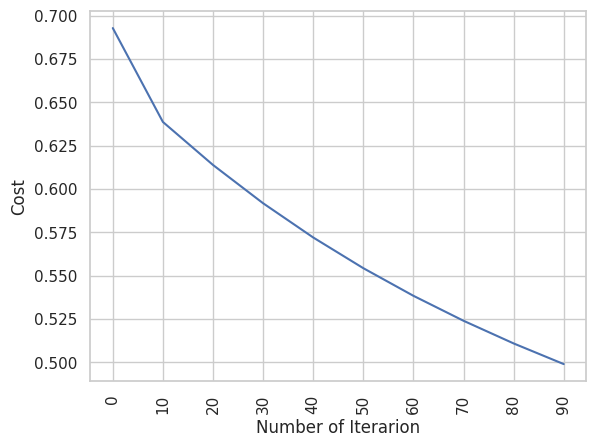

=== NOISE AND ERROR VALUES ===
Noise Level: 10% (0.1)
Training Error: 0.1925
Test Error (Clean): 0.1860
Test Error (Noisy): 0.1744
Error Increase due to Noise: -0.0116


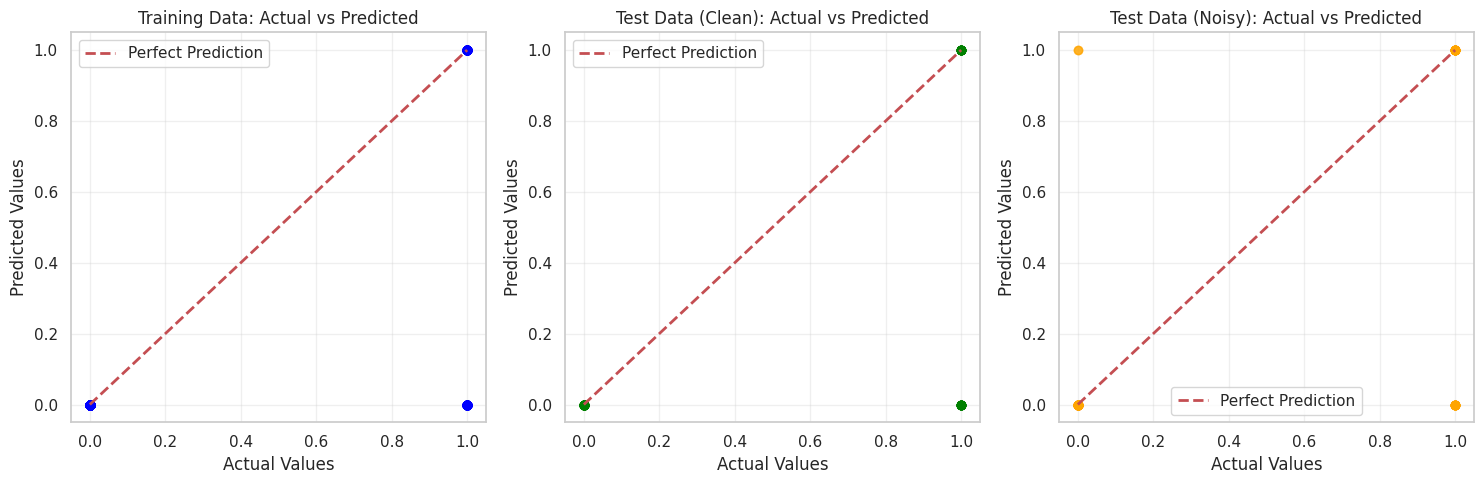


=== SIMPLE ERROR SUMMARY ===
Total Test Samples: 86
Correct Predictions (Clean): 70
Correct Predictions (Noisy): 71
Wrong Predictions (Clean): 16
Wrong Predictions (Noisy): 15

Accuracy (Clean): 81.40%
Accuracy (Noisy): 82.56%
Accuracy Drop: -1.16%


In [26]:
# Cell 14: Add noise to test data and calculate errors
import numpy as np

# Get predictions from your model
dimension = x_train.shape[0]
w, b = initialize_weights_and_bias(dimension)
parameters, gradients, cost_list = update(w, b, x_train, y_train, learning_rate=1, number_of_iterarion=100)

# Get predictions
y_pred_test = predict(parameters["weight"], parameters["bias"], x_test)
y_pred_train = predict(parameters["weight"], parameters["bias"], x_train)

# Add noise to test data
np.random.seed(42)
noise = np.random.normal(0, 0.1, x_test.shape)  # 10% noise
x_test_noisy = x_test + noise
x_test_noisy = np.clip(x_test_noisy, 0, 1)  # Keep values between 0 and 1

# Get predictions with noisy data
y_pred_test_noisy = predict(parameters["weight"], parameters["bias"], x_test_noisy)

# Calculate errors
train_error = np.mean(np.abs(y_pred_train - y_train))
test_error = np.mean(np.abs(y_pred_test - y_test))
test_error_noisy = np.mean(np.abs(y_pred_test_noisy - y_test))

print("=== NOISE AND ERROR VALUES ===")
print(f"Noise Level: 10% (0.1)")
print(f"Training Error: {train_error:.4f}")
print(f"Test Error (Clean): {test_error:.4f}")
print(f"Test Error (Noisy): {test_error_noisy:.4f}")
print(f"Error Increase due to Noise: {test_error_noisy - test_error:.4f}")

# Cell 15: Plot actual vs predicted values
plt.figure(figsize=(15, 5))

# Plot 1: Training data
plt.subplot(1, 3, 1)
plt.scatter(y_train, y_pred_train.flatten(), alpha=0.6, color='blue')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Training Data: Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Test data (clean)
plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_test.flatten(), alpha=0.6, color='green')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Test Data (Clean): Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Test data (noisy)
plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred_test_noisy.flatten(), alpha=0.6, color='orange')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Test Data (Noisy): Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cell 16: Simple error summary
print("\n=== SIMPLE ERROR SUMMARY ===")
print(f"Total Test Samples: {len(y_test)}")
print(f"Correct Predictions (Clean): {np.sum(y_pred_test.flatten() == y_test)}")
print(f"Correct Predictions (Noisy): {np.sum(y_pred_test_noisy.flatten() == y_test)}")
print(f"Wrong Predictions (Clean): {np.sum(y_pred_test.flatten() != y_test)}")
print(f"Wrong Predictions (Noisy): {np.sum(y_pred_test_noisy.flatten() != y_test)}")

# Cell 17: Show the noise effect on accuracy
accuracy_clean = 100 - np.mean(np.abs(y_pred_test - y_test)) * 100
accuracy_noisy = 100 - np.mean(np.abs(y_pred_test_noisy - y_test)) * 100

print(f"\nAccuracy (Clean): {accuracy_clean:.2f}%")
print(f"Accuracy (Noisy): {accuracy_noisy:.2f}%")
print(f"Accuracy Drop: {accuracy_clean - accuracy_noisy:.2f}%")